# Credit Card Fraud Detection — Model Explainability (SHAP)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

C:\Users\KHUSHI\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Model and Test Data

In [2]:
rf = joblib.load('../models/model.pkl')
X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = joblib.load('../data/processed_data.pkl')

X_test.shape

(56962, 30)

## 2. Create SHAP Explainer
Using TreeExplainer (optimized for tree-based models like Random Forest) on a sample of the test set for speed.

In [3]:
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

print(np.array(shap_values).shape)

(500, 30, 2)


## 3. SHAP Summary Plot (Fraud Class)

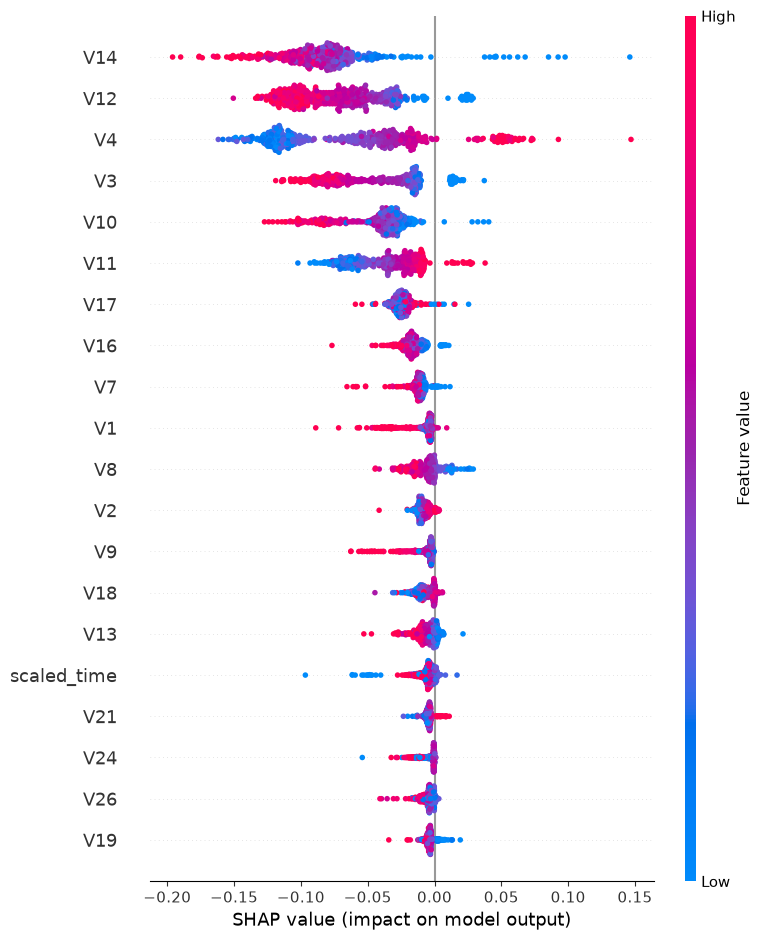

In [4]:
shap.summary_plot(shap_values[:,:,1], X_sample, plot_type='dot')

### How to Read This Plot

This plot shows two things at once for every feature: how much it matters, and whether high or low values of it push a prediction toward fraud or genuine.

| Element | Meaning |
|---|---|
| Each dot | One transaction from the sample |
| Row position (top to bottom) | Features ranked by overall importance |
| X-axis position | Direction and strength of impact on the prediction |
| Right side of center (0) | Pushes prediction toward **fraud** |
| Left side of center (0) | Pushes prediction toward **genuine** |
| Distance from 0 | How strongly that feature mattered for that transaction |
| 🔴 Red dot | Feature had a **high** value for that transaction |
| 🔵 Blue dot | Feature had a **low** value for that transaction |

**Key patterns found:**
- **V14** — blue dots (low values) cluster on the right → low V14 pushes predictions toward fraud. Red dots (high values) cluster on the left → high V14 pushes toward genuine.
- **V4** — opposite pattern: red dots (high values) push toward fraud, blue dots (low values) push toward genuine.
- **V12, V3** — same pattern as V14: low values push toward fraud.

## 4. Explaining a Single Fraud Prediction

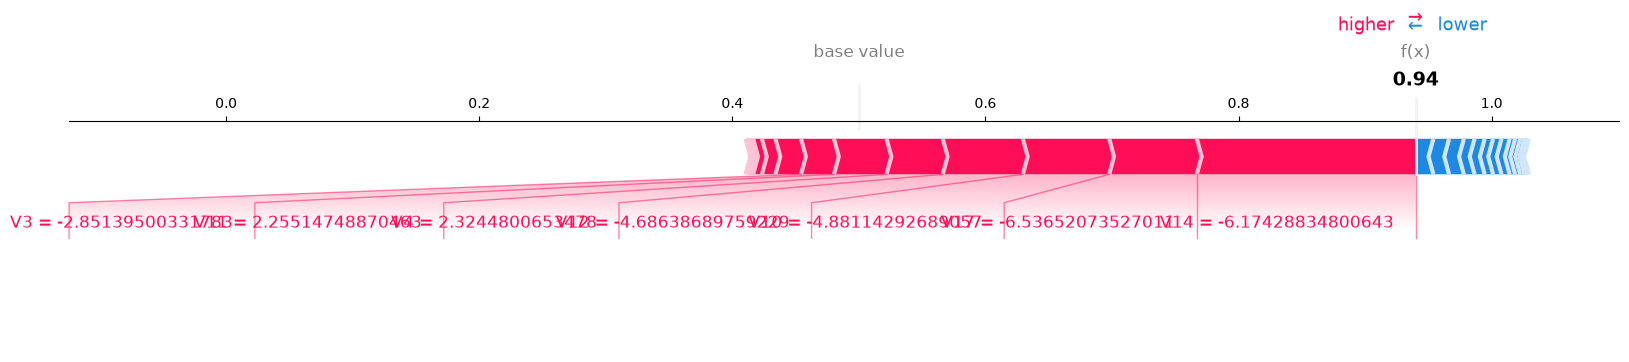

In [5]:
fraud_indices = y_test[y_test == 1].index
sample_fraud_idx = fraud_indices[0]

X_single = X_test.loc[[sample_fraud_idx]]
shap_single = explainer.shap_values(X_single)

shap.force_plot(
    explainer.expected_value[1],
    shap_single[0,:,1],
    X_single,
    matplotlib=True
)

## 5. Summary

- SHAP confirms `V14`, `V12`, `V4`, `V3`, `V10`, `V11`, `V17` as the most influential features — consistent with the correlation analysis from the EDA notebook, showing the model has learned genuine fraud signal rather than noise.
- The summary plot shows the direction of impact: low values on these top features are strongly associated with fraud.
- A single fraud case example shows the model confidently predicting fraud (94% probability), driven primarily by unusually low `V14`, `V10`, and `V12` values.